<a href="https://colab.research.google.com/github/hamnakhan11/hamna/blob/main/Create%20Visualizations%20using%20Matplotlib%2CSeaborn%20and%20Floium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv'
df = pd.read_csv(url)
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


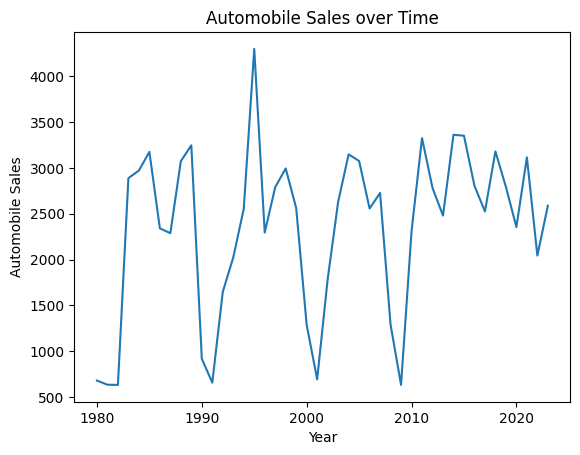

In [ ]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind='line')
plt.xlabel('Year'); plt.ylabel('Automobile Sales'); plt.title('Automobile Sales over Time')
plt.show()

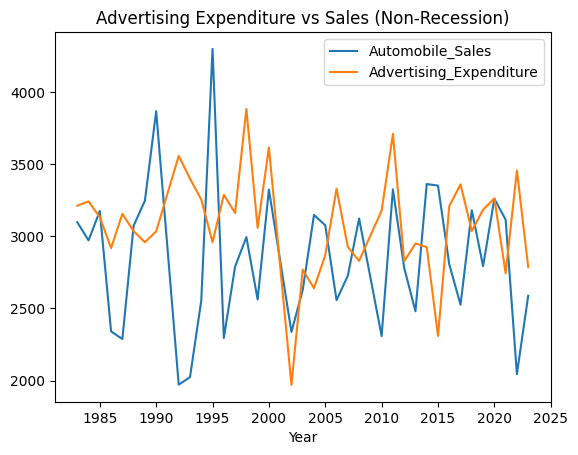

In [ ]:
non_rec = df[df['Recession']==0]
df_group = non_rec.groupby('Year')[['Automobile_Sales','Advertising_Expenditure']].mean()
df_group.plot(kind='line')
plt.title('Advertising Expenditure vs Sales (Non-Recession)')
plt.show()

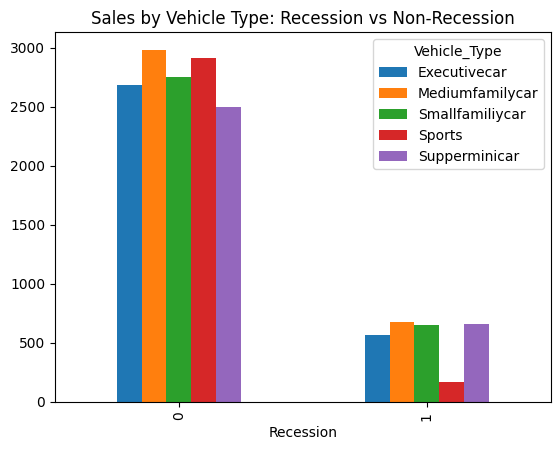

In [ ]:
df_bar = df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().unstack()
df_bar.plot(kind='bar')
plt.title('Sales by Vehicle Type: Recession vs Non-Recession')
plt.show()

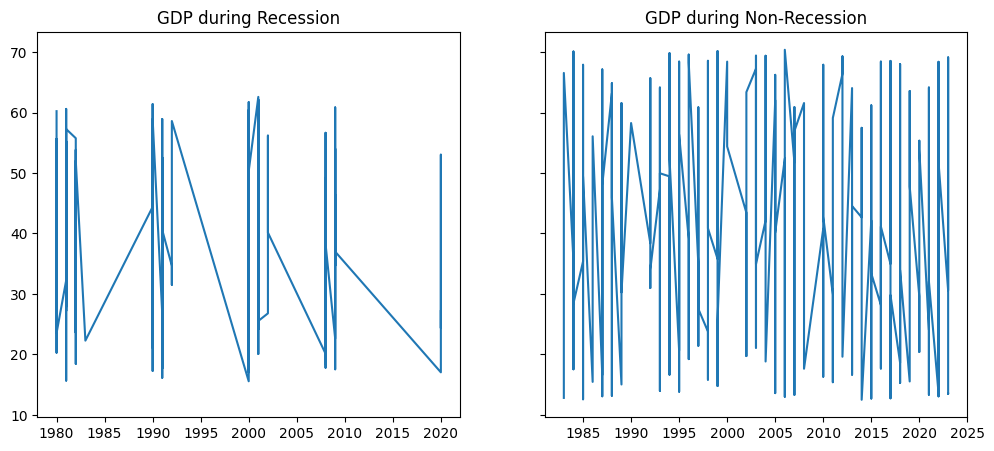

In [ ]:
rec = df[df['Recession']==1]
non_rec = df[df['Recession']==0]
fig, axes = plt.subplots(1,2, figsize=(12,5), sharey=True)
axes[0].plot(rec['Year'], rec['GDP']); axes[0].set_title('GDP during Recession')
axes[1].plot(non_rec['Year'], non_rec['GDP']); axes[1].set_title('GDP during Non-Recession')
plt.show()

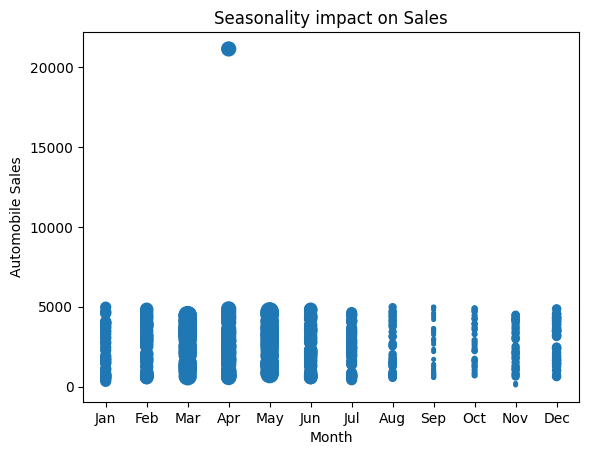

In [ ]:
size = df['Seasonality_Weight']*100
plt.scatter(df['Month'], df['Automobile_Sales'], s=size)
plt.xlabel('Month'); plt.ylabel('Automobile Sales'); plt.title('Seasonality impact on Sales')
plt.show()

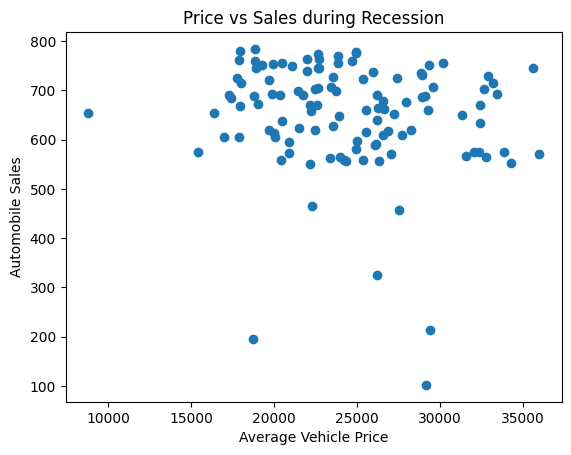

In [ ]:
rec = df[df['Recession']==1]
plt.scatter(rec['Price'], rec['Automobile_Sales'])
plt.xlabel('Average Vehicle Price'); plt.ylabel('Automobile Sales')
plt.title('Price vs Sales during Recession')
plt.show()

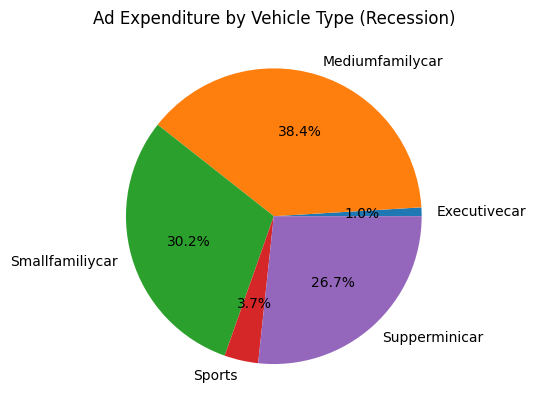

In [ ]:
rec = df[df['Recession']==1]
exp = rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.pie(exp, labels=exp.index, autopct='%1.1f%%')
plt.title('Ad Expenditure by Vehicle Type (Recession)')
plt.show()

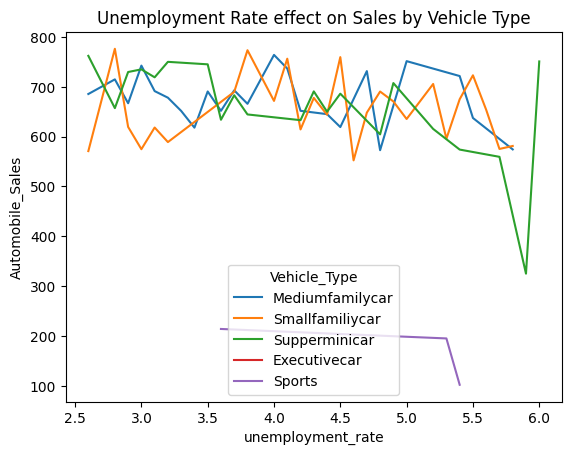

In [ ]:
rec = df[df['Recession']==1]
data = rec.groupby(['unemployment_rate','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
sns.lineplot(data=data, x='unemployment_rate', y='Automobile_Sales', hue='Vehicle_Type')
plt.title('Unemployment Rate effect on Sales by Vehicle Type')
plt.show()

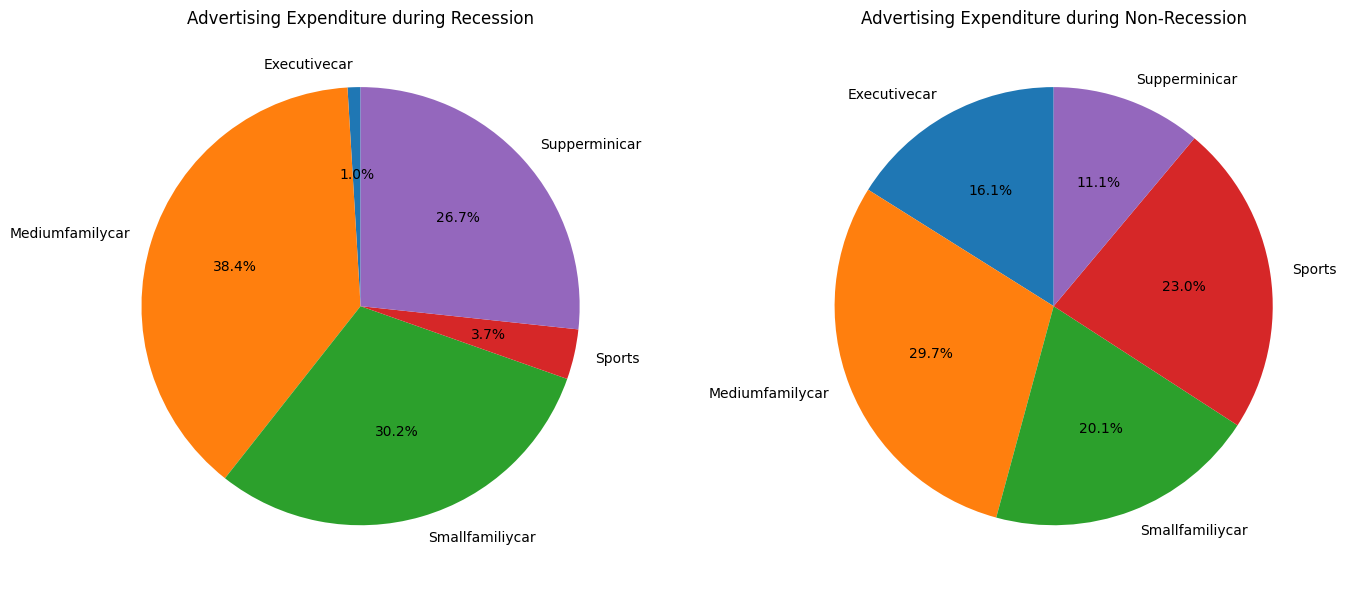

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset load karein taake 'df' define ho jaye
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv'
df = pd.read_csv(url)

# Create a figure with 2 subplots (1 row, 2 columns) for Recession and Non-Recession Advertising Expenditure
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Filter data for Recession and Non-Recession
recession_data = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
non_recession_data = df[df['Recession'] == 0].groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

# Plot pie chart for Recession period
axs[0].pie(recession_data, labels=recession_data.index, autopct='%1.1f%%', startangle=90)
axs[0].set_title('Advertising Expenditure during Recession')

# Plot pie chart for Non-Recession period
axs[1].pie(non_recession_data, labels=non_recession_data.index, autopct='%1.1f%%', startangle=90)
axs[1].set_title('Advertising Expenditure during Non-Recession')

plt.tight_layout()
plt.show()